# Graph neural network - CaMML course

# Introduction: How Graphs Are Helping Us Understand Materials Better



Materials science is all about understanding how atoms come together to form solids — and how these atomic arrangements give rise to useful properties like conductivity, magnetism, or stability.

Thanks to machine learning, we now have powerful new tools to help answer that. One of the most exciting is called a Graph Neural Network (GNN).

Why graphs? Because atoms in a material are naturally connected like a network — each atom linked to its neighbors. This is exactly what a graph is: atoms become nodes, and the connections between them become edges.

Unlike traditional models that flatten this information into a vector (and losing spatial relationships), GNNs preserve the structure and learn by passing messages between atoms. That means they can understand the material in a much deeper way — straight from its geometry and composition.

In this blog, we’ll explore how graph theory, GNNs, convolutions are transforming how we model materials — and why this matters for science and technology.




# Graph Theory

To apply GNNs to materials, we first need to understand the graph theory that underpins the method. Graph theory provides the mathematical foundation for representing atomic structures.

A graph G = (V,E), where V is the set of nodes (or vertices) and E the set of edges.

In Materials science,

Nodes (Vertices): Each atom in the material becomes a node in the graph. Node features may include atomic number, valence electrons, or electronegativity.

Edges (Links): Represent the connections between atoms—these can be direct chemical bonds or neighbors within a cutoff distance (e.g., 3.0 Å). Edge features may include bond length, bond type, or even directionality.

Graph: A complete material structure can then be modeled as a graph, where the spatial arrangement and types of atoms are preserved.

Adjacency Matrix: A matrix A of size N × N (where N is the number of atoms):

- 𝐴𝑖𝑗 = 1 if atoms 𝑖 and 𝑗 are connected within the cutoff,
- 𝐴𝑖𝑗 = 0 otherwise.

When we use convolution (filter) on these graphs — like in CGCNN — we're trying to help the model learn how each atom is influenced by its neighbors.

CGCNN applies the convolution operation to capture both local and global features from the crystal graph, helping predict properties like formation energy.

The idea is simple: each atom gathers information from the atoms it's connected to. This is great because it helps the model understand how atoms interact locally. But if we do this gathering — this "convolution" — too many times, something happens: the atom starts getting information from too many other atoms, even ones far away. It’s like trying to understand your neighborhood by asking friends, then your friends’ friends, and so on. After a while, the information gets so mixed up that you lose the details about your own block.

This is what we mean when we say you lose the specificity of location. The atom’s original, unique position and role in the structure gets blurred.

So, while convolution helps capture patterns and relationships in a graph, doing it too much can make all atoms start to look the same. In materials science, that’s a problem — because tiny local differences can mean very different material properties.

In short:
Graph convolution helps atoms learn from their neighbors — but too much of it, and you lose what makes each atom special.

In this blog, we explore how GNNs can predict the formation energy of materials — a key thermodynamic property that tells us how stable a structure is. Using data from the [Material Project](https://legacy.materialsproject.org/), we show how to convert real crystal structures into graphs, and how to train a GNN to predict energy from structure.

# How to do a GNN?

Thanks to this approach we can transform the theory into an useable algorithm.

To do so, we will take the time to build piece by piece our own GNN in this section. 

First of all, we need to have access to a sufficient amount of data to train our GNN, for this, the __[Material Project](https://legacy.materialsproject.org/)__ database will be used. Even if we could train our GNN upon any property, we will only focus on the prediction of the formation energy of the solid using its structure and its composition.

The extraction and handeling of the data will be similar to what is shown in the [matminer tutorial](https://github.com/hackingmaterials/matminer_examples/blob/main/matminer_examples/).

In [1]:
# Here we will take some libraries to construct the neural-networks using torch.
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

# Here are some diverse modules and functions necessary.
import random
import time

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

# ASE and pymatgen modules
from pymatgen.io.ase import AseAtomsAdaptor
from ase.neighborlist import neighbor_list

# matminer
# Be mindful that the MPDataRetrieval only works for the old MP data base!

from matminer.data_retrieval.retrieve_MP import MPDataRetrieval

## Data aquisition

In [2]:
# To ensure a reproducible results, we put the same random seed.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [4]:
mpdr = MPDataRetrieval("") # I am using MP because the other one crashes and I have enough of waiting 1h just for it to crash.

/home/lorentyfle/test/.venv/lib/python3.10/site-packages/pymatgen/ext/matproj.py:419: FutureWarning: You are using the legacy MPRester. This version of the MPRester will no longer be updated. To access the latest data with the new MPRester, obtain a new API key from https://materialsproject.org/api and consult the docs at https://docs.materialsproject.org/ for more information.
  return _MPResterLegacy(*args, **kwargs)


In [5]:
# Can be long (~10min to grab all the necesary 126335 datas).
df = mpdr.get_dataframe(criteria={}, properties=['formation_energy_per_atom', 'pretty_formula',"structure"])

100%|██████████| 126335/126335 [10:49<00:00, 194.65it/s]


Now that the data base is ready, with only three columns needed to train our GNN upon:
 - The composition
 - The structure
 - The formation energy (the property we wish to predict)
 

In [24]:
df

,formation_energy_per_atom,pretty_formula,structure
material_id,,,
mp-1001788,-0.020860,ZrB6,"[[0. 0. 0.] Zr, [0.80207057 2.029387 2.02938..."
mp-1002206,0.537123,SiC,"[[0. 0. 0.] Si, [2.0251 2.0251 2.0251] C]"
mp-1004524,0.234287,HPbI3,"[[3.1221065 3.1221065 3.1221065] H, [0. 0. 0.]..."
mp-1008492,-0.349239,BrCl,"[[0. 0. 0.] Br, [0. 0. 3.9053505..."
mp-1011260,-2.517135,EuFeO3,"[[ 2.747224 2.72097164 -1.9501425 ] Eu, [5...."
...,...,...,...
mvc-5634,-2.022086,Ca2CuIrO6,"[[3.15778709 8.03614231 5.77105139] Ca, [0.340..."
mvc-6019,-1.619846,Zn(SnO2)2,"[[ 0. 11.36829898 1.84505467] Zn, [0...."
mvc-8011,-1.584384,ZnFeAs2O7,"[[0.71270026 8.84632777 7.89206318] Zn, [5.112..."


If we then look at the repartition of the *formation energy per atom* in function of the database, we have the histogram below.

[Text(0.5, 0, '$\\mathrm{E}_\\mathrm{f}/\\mathrm{atom}$'),
 Text(0, 0.5, 'Number of examples')]

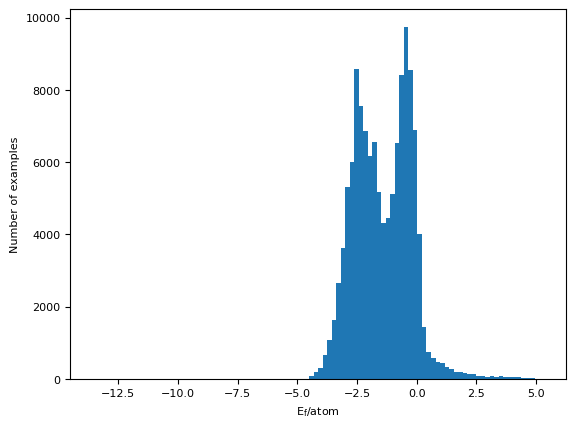

In [25]:
fig, ax = plt.subplots()
ax.hist(df["formation_energy_per_atom"], bins=100)
ax.set(xlabel="$\mathrm{E}_\mathrm{f}/\mathrm{atom}$", ylabel="Number of examples")

## Transforming the data into a graph.

    Transforming a structure into a graph.

At last we have a curated database in function of the target property, the formation energy.

Yet, we still lacks a graph representation of the structure using node and edges. To do so, we can say that each atoms of each structures are a **node** and, their neigbhor the **edges**.

    Encoding information.

As the edge and the node is defined, one last step still remains before the data is ready, we need to encode some informations inside the node and the edge to allow the machine learning to know the difference in between a Li next to an O and a I next to a Fe.


_Where can we encode the information?_

Saving information inside the node seems very intuitive because we simply say that one node is one atom, such that the information of the atom type seems obvious.

As for the interactions, we can store this information inside the edges of the node, this is the **edge embedding**.

The simplest edge embedding would be the atomic connexion; yet, we can also store further informations like the bond length, the bond angle, etc...

Here we will be modest and only keep the atomic connexion and the bond length as edge features.

### The Node: Encoding the nature of the atom

To encode the nature of the atom, one simple way would be to make an array of 118 entries (for each atoms), then put a 1 where this atom is inside the periodic table of elements.

This method called *one hot encoding* is here useful because it will reduce drastically the memory needed to identify the data base while being really easy to read.

In [8]:
def one_hot_encode_z(atomic_number:int):
    """We return a onehot encoding of the periodic table of elements, inputting the Z number gives the good onehot encoding for the atom in question."""
    vector = np.zeros(118)
    vector[atomic_number-1] = 1
    return vector

In [ ]:
node_features = torch.tensor(np.array([one_hot_encode_z(site.species.elements[0].Z) for site in df["structure"].iloc[0]]))
# Here our atom is Zr with Z=40, so we look at the 39th place to find it back.
print(node_features[0][39])
print(node_features[0])

tensor(1., dtype=torch.float64)
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=torch.float64)


/tmp/ipykernel_238008/1130799710.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:230.)
  node_features = torch.tensor([one_hot_encode_z(site.species.elements[0].Z) for site in df["structure"].iloc[0]])


### The Edge : Keeping track of the atom connexions.

Keeping track of the atom connexion is not as hard has one may think. Indeed, we can simply use a prebuilt function inside [`ase`](https://wiki.fysik.dtu.dk/ase/) to output the list of neighboring connexions and their length given a cutoff radius.

In [314]:
cutoff_radius = 4 # Angstrom

In [315]:
atoms = AseAtomsAdaptor.get_atoms(df["structure"].iloc[0])
edge_src, edge_dst, edge_len = neighbor_list(
                "ijd", atoms, cutoff=cutoff_radius, self_interaction=False
            )
# Cell parameter of atoms
atoms.cell

Cell([4.058774, 4.058774, 4.058774])

The three variables show the origin of the bond, its destination and the length.
In fact, if we visualize the graph of the connections it becomes evident that for such a crystal structure with cell parameters almost equal to $4 \AA$, each of the atoms will be connected.

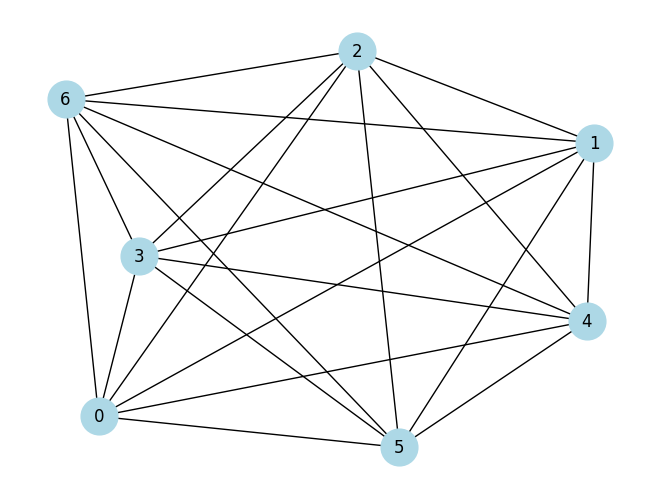

In [316]:
G = nx.Graph()
for s1, s2 in zip(edge_src, edge_dst):
    G.add_edge(s1, s2)
nx.draw(G, with_labels=True, node_color='lightblue', node_size=700, font_size=12)
plt.show()

A simple approach to embbed the distances without having to create our own convolution would be to describe the edge feature as a weight on the node convolution.

One can take one node (black) connected to two other nodes (red and blue). 
![Edge_embedding](./pictures/edge_embedding.png)![Edge_embedding_wrong_weight](./pictures/edge_embedding_no_weight.png)

If no weight was involved than both of the red and blue nodes will have an equal involvment on the central node, which make this approximation inadequate.

![Edge_embedding_wrong_weight](./pictures/edge_embedding_with_weight.png)

If the convolution effect is decreased with the distance then it would reduce the amount of information given by far away atoms, which will add a small spatial contribution.


Thanks to a value of the distance that cannot excess a cutoff radius, then a normalisation of the distance followed by an inversion would be enough to create the weigths.

$$w_i = 1-\frac{d}{r_c}$$

Where $w_i$ is the weight of the edge, $d$ is its length and $r_c$ is the cutoff radius of the edge (no edge can have a distance superior to this cutoff).

## Storing the data

Once we did all of this, we can try to store all this informations inside a Data class that will possess all the informations of our database.

In [509]:
from torch_geometric.data import Data
from tqdm import tqdm
# Parameters for encoding bond lengths
cutoff_radius = 4.0 
number_of_random_structures_taken = 1000

gaussian_number = 50
filter = np.linspace(0, cutoff_radius, number_of_gaussians)
# Initialize an empty list to store Data objects
data_list = []

# I take a smaller sample size to go quicker. Only random structures are here taken to not be biased.
sampled_df = df.sample(n=number_of_random_structures_taken, random_state=SEED)

# Loop through each entry in the DataFrame
for entry in tqdm(range(sampled_df.shape[0])):
    # Extract ASE Atoms object from the structure
    atoms = AseAtomsAdaptor.get_atoms(df["structure"].iloc[entry])
    
    # Use neighbor_list to compute edge_src, edge_dst, and edge_len
    edge_src, edge_dst, edge_len = neighbor_list(
        "ijd", atoms, cutoff=cutoff_radius, self_interaction=False
    )
    
    # Setup edge_distance to weight the edges.
    edge_distance=torch.tensor(1.0 - np.array(edge_len)/cutoff_radius,dtype=torch.float32)

    # Create node features (example: one-hot encode atomic numbers)
    node_features = torch.tensor([
        one_hot_encode_z(site.species.elements[0].Z)
        for site in df["structure"].iloc[entry]
    ], dtype=torch.float)
    
    
    edge_feat = np.exp(
        -((edge_len[..., None] - filter) ** 2) / (filter[1] - filter[0]) ** 2
    )
    edge_feat = torch.tensor(edge_feat, dtype=torch.float)

    # Create edge_index from edge_src and edge_dst
    edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)

    # Setup the target of our small GNN
    target = torch.tensor(sampled_df["formation_energy_per_atom"].iloc[entry], dtype=torch.float)

    # Setup the batch 
    batch_ind = torch.tensor([entry]*len(node_features))
    # Create a Data object for the current entry
    data = Data(
        x=node_features,        # Node features
        edge_index=edge_index,  # Edge connections
        edge_len=edge_distance, # Edge features (length)
        edge_feat=edge_feat,
        batch=batch_ind,        # Which graph/structure each nodes belongs to.
        y=target,                # Target property to investigate
        #atoms=atoms
    )
    
    # Append the Data object to the list
    data_list.append(data)


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:51<00:00, 19.49it/s]


Now that our data base is created, we can start to split it up in between a **training set**, a **testing set** and a **validation set**.

 - The training set is the set of data that will be used for training the model.
 - The validation set is the set of data that will be used to help the training of the model by showing verifications on untrained data, giving a score to train once again.
 - The testing set is the set of data that will be used to know how well the model can predict on unseen datas.

In [510]:
# State in percentage the amount of training, testing and validation data. It must be equal to 1 at the end.
proportions = [0.8,0.1,0.1]
batch_size  = 32

In [511]:
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

def proportion_to_percentage(proportion:list,precision:int=4):
    """proportion = [training, testing, validation]"""
    if round(sum(proportion),precision) != 1:
        raise ValueError("The sum of all proportions of the data cannot be different from 1.")
    # Training split
    train_split = round(1 - proportion[0],precision)
    # Testing split
    test_split  = round((1 - proportion[1]/(proportion[1]+proportion[2])),precision)
    return train_split, test_split

def flattening_data(to_cat:list):
    """Functions that flatten the array of Data into a single Data."""
    flatten = Data(
            x=torch.cat([_data.x for _data in to_cat],dim=0),
            edge_index=torch.cat([_data.edge_index + sum(_data.x.size(0) for _data in to_cat[:i]) for i, _data in enumerate(to_cat)], dim=1),
            edge_len=torch.cat([_data.edge_len for _data in to_cat],dim=0),
            edge_feat=torch.cat([_data.edge_feat for _data in to_cat],dim=0),
            batch=torch.cat([_data.batch for _data in to_cat],dim=0),
            y=torch.tensor([_data.y for _data in to_cat])
        )
    return flatten

In [512]:
train_split, test_split = proportion_to_percentage(proportions)
#
train_data, temp_data = train_test_split(data_list, test_size=train_split, random_state=SEED)
test_data, val_data   = train_test_split(temp_data, test_size=test_split, random_state=SEED)
#

In [513]:
print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(val_data)}')
print(f'Number of testing examples: {len(test_data)}')

Number of training examples: 800
Number of validation examples: 100
Number of testing examples: 100


Here the batches have two purposes, splitting the datas to increase the computational time and handeling multiple graphs simultaneously, thanks to the `collate_fn` that would flatten the data_list().

Here the **batch** property in the flattened database allows to keep track which graph each atom belongs to.

In [514]:
# Create a DataLoader for batching the graphs
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=False,collate_fn=flattening_data) # We do not want correlation of the input order for the training data
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False,collate_fn=flattening_data)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False,collate_fn=flattening_data)

## Making the GNN

To construct the GNN, we can split the task into two parts:
 - GNN class
 - Training and evaluation function

### GNN class

Here, the data is in the form of a graph that can be processed.
Indeed, to make it go through a neural network we can think of three main steps that can be applied.
1) The Message.

> The message is the information passed from one node to another.

Here, the message that needs to be passed to the node $i$ is a vector of all the features surrounding said node, such as the neighboring node information and its edge information.

To improve the efficiency of our GNN and to train our model on the atom nature, we can embed our *one-hot* node encoding, so representing it into a continuous vector space of lower dimension, using `nn.Linear`.

![Picture_node](./pictures/node_embedding.png)

2) The Pooling

> The pooling is the way the messages from all neighbors are combined.

As it was discussed in the first part, we can pool the messages by performing a convolution on the neigbhors and edges embeddings.
In the sake of simplicity, a built in convolution class will here be used `nn.conv.GraphConv` that will perform a graph convolution on only the nodes given their connections. To add a small amount of information from the edges, they will be weighted by the distance as it was discussed previously.

3) The Update

> The update is how the node `i` is updated given the pooled message.

The results of the convolution will here update the node `i` vector of features with the informations from its neighbors.
Yet, we are interested a **graph level property** prediction, the **formation energy** of the structure.

To do so, another pooling will be done over all the nodes using `torch_scatter.scatter_mean`, following this formula:

$$\bold{u}_c = \sum_{i\in G} \frac{\bold{v}_{i}^{(T)}}{|G|}$$

Where $\bold{u}_c$ is the vector for final pooling of the nodes, $G$ is the number of atoms and $\bold{v}_{i}^{(T)}$ is the vector of features of the node $i$ after the convolution from the neigbhors.

Thanks to this three steps we have the vector that describes the graph of the structure.

Such that, updating the GNN using $u_c$ over the target property, the formation energy of the structure, would only require an MLP readout (Multilayer Perceptron) using the `nn.Linear` class and a non-linear activation function like a sigmoid.
It can be written as the following formula:

$$E_{f_c} = \sigma \left( \bold{W}_{r} \bold{u}_{c} + \bold{b}_{r} \right)$$

Where $E_{f_c}$ is the readout of the MLP for the fully connected feature dimension $f_c$ accross all structures, $\bold{W}_{r}$ is the weight matrix and $\bold{b}_{r}$ is the bias vector.

![Sigmoid_function_plot](./pictures/sigmoid.png)

Since $E_{f_c}$ is in between 0 and 1, only using a linear transformation over all the fully connected feature vector would allow to obtain a scalar that is fitted by the formation energy.


The skeleton of the GNN created can be visualised below:

![Plan_full_GNN](./pictures/full_GNN_algorithm.png)

In [ ]:
from torch_geometric.nn.conv import GraphConv
from utils import scatter_mean # 

class GNN(torch.nn.Module):
    def __init__(self,
        node_feat_dim,
        node_hidden_dim=64,
        num_graph_conv_layers:int=3,
        fc_feat_dim:int=128,
        ):
        # Using the super() class we can then say that our own GNN class is an extension of the nn.Module, stating that we have a Neural Network.
        super(GNN, self).__init__()

        # dense layer to transform one-hot encoded node features to embedding
        self.embedding = nn.Linear(node_feat_dim, node_hidden_dim)

        # set up the convolutions of GraphConv
        convs = []
        for _ in range(num_graph_conv_layers):
            convs.append(GraphConv(node_hidden_dim, node_hidden_dim,aggr="mean"))
        self.convs = nn.ModuleList(convs)

        # dense layer to turn final node embeddings to the crystal features
        self.conv_to_fc = nn.Sequential(
           nn.Linear(node_hidden_dim, fc_feat_dim), nn.Softplus()
        )

        # dense layer to get the final target value
        self.fc_out = nn.Linear(fc_feat_dim, 1)

    def forward(self, batch):
        """
        Predict the target property given a batch of data.

        Parameters
        ----------
        batch : Batch
            The data to pass through the network.
        """
        # get initial node embedding
        node_feat = self.embedding(batch.x) ## Here x is the one-hot encoding of the nodes

        # apply convolutions
        for conv_func in self.convs:
        #            # forward( x = node_features, edge_index, edge_weight:Optional) -> Tensor
            node_feat = conv_func(node_feat, batch.edge_index, batch.edge_len )

        # pool node vectors
        crys_feat = scatter_mean(node_feat, batch.batch, dim=0, dim_size=batch.batch.max() + 1)

        # pass pooled vector through Fully Connected layer with activation
        crys_feat = self.conv_to_fc(crys_feat)

        # pass crystal features through final fully-connected layer        
        return self.fc_out(crys_feat)

### Training and evaluation function

Now that the class for the model is done, we need to train and evaluate it, for the validation and the testing of the model.


To do so, the training and evaluation functions are created. Both of the functions are here using a criterion function to determine the losses and compute the MAE (Mean Absolute Error) using the nn.L1loss() function.

Here the loss measure the difference in between the predicted value and the actual target value, while the MAE measure the average magnitude of errors between the predicted and actual values.

Thanks to these tool of prediction it would then be possible to identify the accuracy of a model during and after its training.

Furthermore, the training function will then **backpropagate** the losses to allow to compute the gradient of the losses in function of the model's parameters and propagating the losses backward through each layer of the network. Finally, this gradient losses will then be intercepted by a **Stochastic Gradient Descent** algorithm that will update the model parameters from the previous layers of the network accordingly.

In [460]:
def train(dataloader, model, optimizer, criterion):
    epoch_loss = 0
    epoch_mae = 0
    
    model.train()
    
    for i, batch in enumerate(dataloader):
        # move the data onto the GPU if available
        # compute output
        y_pred = model(batch)
        loss = criterion(y_pred, batch.y)
        mae = nn.L1Loss()(y_pred, batch.y)
        
        # compute gradient
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # update metrics
        epoch_loss += loss.item()
        epoch_mae += mae.item()
        
    return epoch_loss / len(dataloader), epoch_mae / len(dataloader)

def evaluate(dataloader, model, criterion):
    epoch_loss = 0
    epoch_mae = 0
    
    model.eval()

    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            
            # compute output
            y_pred = model(batch)
            loss = criterion(y_pred, batch.y)
            mae = nn.L1Loss()(y_pred, batch.y)
                   
            # update metrics
            epoch_loss += loss.item()
            epoch_mae += mae.item()
        
    return epoch_loss / len(dataloader), epoch_mae / len(dataloader)

### Run the GNN

In [ ]:
# Instantiate the model
hidden_channels = 64
max_epoch       = 40

in_node_features = node_features.shape[1]##Because the one-hot encoding is the same for all the nodes, we can take this value.
model = GNN(in_node_features, hidden_channels,num_graph_conv_layers=3,fc_feat_dim=32)

# Optimizer and loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # We use a basic Adam optimizer.
criterion = torch.nn.MSELoss()  # Use CrossEntropyLoss for classification tasks

start_time = time.time()
save_losses_train = []
save_losses_valid = []
save_mae_train = []
save_mae_valid = []
# Using the DataLoaders for training and validation
for epoch in range(0,max_epoch):
    train_loss,train_mae = train(train_loader,model,optimizer,criterion)
    val_loss,valid_mae = evaluate(val_loader,model,criterion)
    # Save validation and losses.
    save_losses_train.append(train_loss)
    save_losses_valid.append(val_loss)
    save_mae_train.append(train_mae)
    save_mae_valid.append(valid_mae)
    #
    epoch_time = time.time() - start_time
    print(f'Epoch: {epoch+1:02} | Train MAE: {train_mae:8.4f} | Valid MAE: {valid_mae:8.4f}'
         f' |   Elapsed time: {time.strftime("%M min %S s", time.gmtime(epoch_time))}')
# Test the model
test_loss,test_mae = evaluate(test_loader,model,criterion)
print(f'Test Loss: {test_loss:.4f} | Test MAE: {test_mae:.4f}')

Epoch: 01 | Train MAE:   1.0506 | Valid MAE:   0.9764 |   Elapsed time: 00 min 00 s
Epoch: 02 | Train MAE:   1.0120 | Valid MAE:   0.9786 |   Elapsed time: 00 min 00 s
Epoch: 03 | Train MAE:   1.0140 | Valid MAE:   0.9845 |   Elapsed time: 00 min 01 s
Epoch: 04 | Train MAE:   1.0140 | Valid MAE:   0.9834 |   Elapsed time: 00 min 01 s
Epoch: 05 | Train MAE:   1.0138 | Valid MAE:   0.9824 |   Elapsed time: 00 min 01 s
Epoch: 06 | Train MAE:   1.0139 | Valid MAE:   0.9818 |   Elapsed time: 00 min 01 s
Epoch: 07 | Train MAE:   1.0140 | Valid MAE:   0.9814 |   Elapsed time: 00 min 02 s
Epoch: 08 | Train MAE:   1.0141 | Valid MAE:   0.9813 |   Elapsed time: 00 min 02 s
Epoch: 09 | Train MAE:   1.0144 | Valid MAE:   0.9810 |   Elapsed time: 00 min 02 s
Epoch: 10 | Train MAE:   1.0148 | Valid MAE:   0.9827 |   Elapsed time: 00 min 02 s
Epoch: 11 | Train MAE:   1.0145 | Valid MAE:   0.9820 |   Elapsed time: 00 min 03 s
Epoch: 12 | Train MAE:   1.0146 | Valid MAE:   0.9805 |   Elapsed time: 00 m

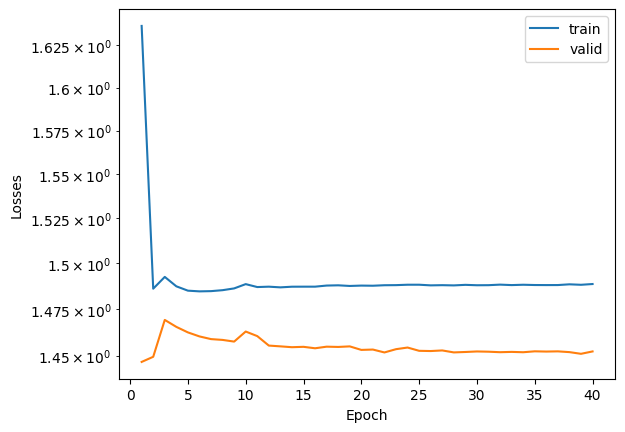

In [472]:
fig, ax = plt.subplots()
ax.plot(range(1,max_epoch+1), save_losses_train, label="train")
ax.plot(range(1,max_epoch+1), save_losses_valid, label="valid")
ax.set(xlabel="Epoch", ylabel="Losses")
ax.set_yscale("log")
plt.legend()

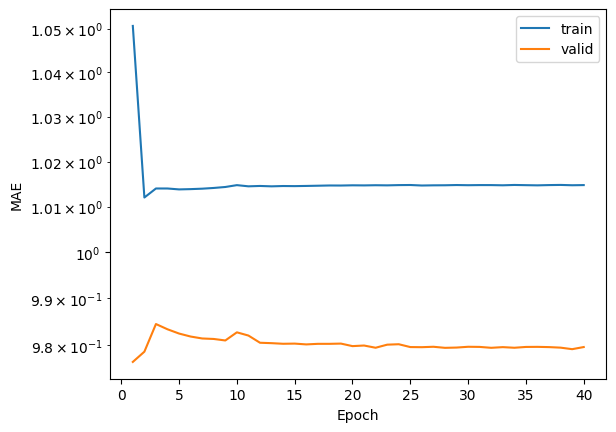

In [473]:
fig, ax = plt.subplots()
ax.plot(range(1,max_epoch+1), save_mae_train, label="train")
ax.plot(range(1,max_epoch+1), save_mae_valid, label="valid")
ax.set(xlabel="Epoch", ylabel="MAE")
ax.set_yscale("log")
plt.legend()

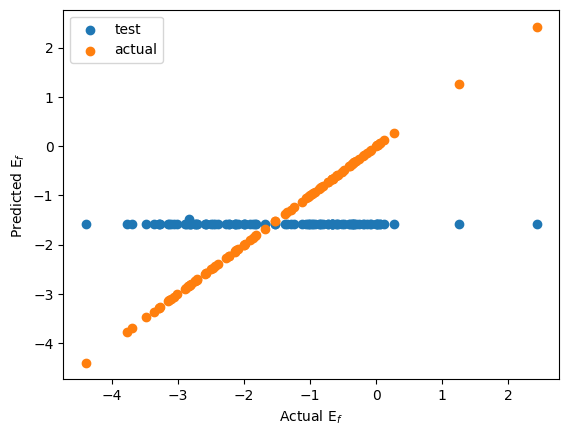

In [487]:
import matplotlib.pyplot as plt

actual = []
predicted = []

model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        y_pred = model(batch)
        predicted.extend(y_pred.data.cpu().tolist())
        actual.extend(batch.y.tolist())
        
fig, ax = plt.subplots()
ax.scatter(np.array(actual), np.array(predicted), label="test")
ax.scatter(np.array(actual), np.array(actual), label="actual")
ax.set(ylabel="Predicted E$_{f}$", xlabel="Actual E$_{f}$")
plt.legend()

Here the GNN is not sufficient to fit sufficiently $E_f$ with only the bias that was fitted successfully. However, this result can be explained by the fact the model created is not that expressive, with no descriptor of the surroundings that could have been done using gaussians or a SOAP descriptor for example. Also, the amount of data was too small for the diversity of different structures that can be found in material project legacy.

The construction of a simple GNN was indeed successfull, yet; we can easily see the limits of our approximations by taking such a diverse amount of datas. This can be tackled by using a GNN that are more complex that asses of more degrees of freedom, leading to Universal Machine Learning Force Fields such as NequIP, or MACE.

/home/lorentyfle/test/.venv/lib/python3.10/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/lorentyfle/test/.venv/lib/python3.10/site-packages/torch/nn/modules/loss.py:128: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
/home/lorentyfle/test/.venv/lib/python3.10/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([4])) that is different to the input size (torch.Size([4, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure the

Epoch: 01 | Train MAE:   1.0585 | Valid MAE:   0.9735 |   Elapsed time: 00 min 02 s
Epoch: 02 | Train MAE:   1.0334 | Valid MAE:   0.9567 |   Elapsed time: 00 min 04 s
Epoch: 03 | Train MAE:   1.0263 | Valid MAE:   0.9435 |   Elapsed time: 00 min 11 s
Epoch: 04 | Train MAE:   1.0295 | Valid MAE:   0.9695 |   Elapsed time: 00 min 19 s
Epoch: 05 | Train MAE:   1.0264 | Valid MAE:   1.0852 |   Elapsed time: 00 min 26 s
Epoch: 06 | Train MAE:   1.0259 | Valid MAE:   0.9836 |   Elapsed time: 00 min 32 s
Epoch: 07 | Train MAE:   1.0240 | Valid MAE:   0.9933 |   Elapsed time: 00 min 38 s
Epoch: 08 | Train MAE:   1.0206 | Valid MAE:   0.9992 |   Elapsed time: 00 min 46 s
Epoch: 09 | Train MAE:   1.0185 | Valid MAE:   0.9798 |   Elapsed time: 00 min 54 s
Epoch: 10 | Train MAE:   1.0177 | Valid MAE:   0.9928 |   Elapsed time: 01 min 01 s
Epoch: 11 | Train MAE:   1.0164 | Valid MAE:   0.9866 |   Elapsed time: 01 min 08 s
Epoch: 12 | Train MAE:   1.0158 | Valid MAE:   0.9915 |   Elapsed time: 01 m

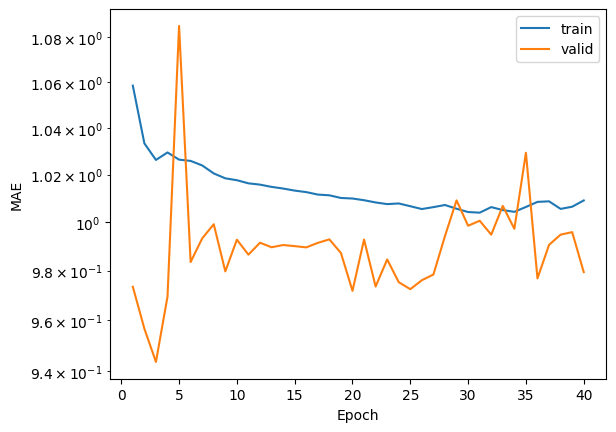

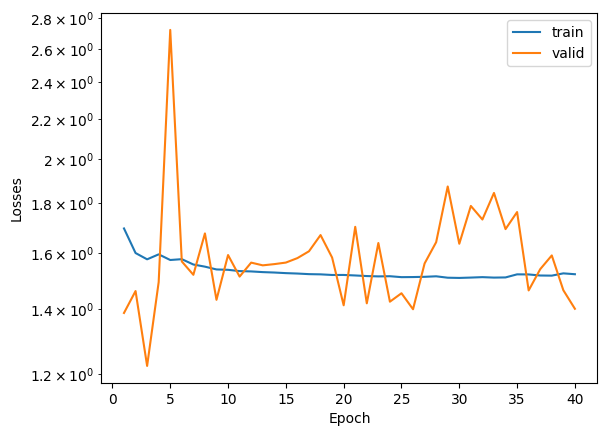

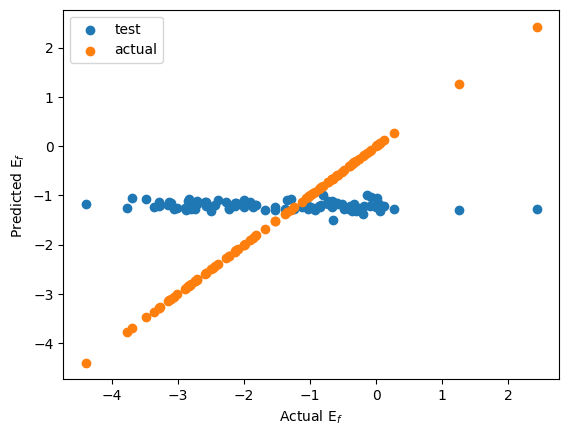

In [ ]:
### Comparison with CGCNN to verify the model (will be removed at the end)
from utils import scatter_sum, scatter_mean

class GraphConvolution(nn.Module):
    
    def __init__(self, node_feat_dim, edge_feat_dim):
        """
        Convolutional layer for graphs.
        
        Parameters
        ----------
        node_feat_dim : int
          Number of node features.
        edge_feat_dim : int
          Number of edge features.
        """
        super().__init__()

        # linear layer used for the gated MLP
        self.lin1 = nn.Linear(
            2 * node_feat_dim + edge_feat_dim,
            2 * node_feat_dim,
        )

        # normalisation layers
        self.bn1 = nn.BatchNorm1d(2 * node_feat_dim)
        self.bn2 = nn.BatchNorm1d(node_feat_dim)

    def forward(self, node_feat, edge_feat, edge_src, edge_dst):
        """Perform the convolution.

        Parameters
        ----------
        node_feat : Tensor
            The node features.
        edge_feat : Tensor
            The edge features
        edge_src : Tensor
            The indices of the central nodes for the edges.
        edge_dst : Tensor
            The indices of the desintation nodes for the edges.
        """
        # concatenate node and edge features
        m = torch.cat([node_feat[edge_src], node_feat[edge_dst], edge_feat], dim=1)

        # gated MLP
        z = self.lin1(m)
        z = self.bn1(z)
        z1, z2 = z.chunk(2, dim=1)
        z1 = nn.Sigmoid()(z1)
        z2 = nn.Softplus()(z2)
        z = z1 * z2

        # pool features
        z = scatter_sum(z, edge_src, dim=0, dim_size=node_feat.shape[0])
        
        # pass through normalisation layer
        return nn.Softplus()(self.bn2(z) + node_feat)

class CGCNN(nn.Module):
    def __init__(
        self,
        node_feat_dim,
        edge_feat_dim,
        node_hidden_dim=64,
        num_graph_conv_layers=3,
        fc_feat_dim=128
    ):
        """
        Crystal Graph Convolutional Neural Network 

        Parameters
        ----------
        node_feat_dim : int
          Number of initial node features from one-hot encoding.
        edge_feat_dim : int
          Number of bond features.
        node_hidden_dim : int
          The number of features in the node embedding.
        num_graph_conv_layers: int
          Number of convolutional layers.
        fc_feat_dim: int
          Number of hidden features after pooling.
        """
        super().__init__()

        # dense layer to transform one-hot encoded node features to embedding
        self.embedding = nn.Linear(node_feat_dim, node_hidden_dim)

        # set up the convolutions
        convs = []
        for _ in range(num_graph_conv_layers):
            convs.append(GraphConvolution(node_feat_dim=node_hidden_dim, edge_feat_dim=edge_feat_dim))
        self.convs = nn.ModuleList(convs)

        # dense layer to turn final node embeddings to the crystal features
        self.conv_to_fc = nn.Sequential(
           nn.Linear(node_hidden_dim, fc_feat_dim), nn.Softplus()
        )

        # dense layer to get the final target value
        self.fc_out = nn.Linear(fc_feat_dim, 1)

    def forward(self, batch):
        """
        Predict the target property given a batch of data.

        Parameters
        ----------
        batch : Batch
            The data to pass through the network.
        """
        # get initial node embedding
        node_feat = self.embedding(batch.x)

        # apply convolutions
        for conv_func in self.convs:
            node_feat = conv_func(node_feat, batch.edge_feat, batch.edge_index[0], batch.edge_index[1])

        # pool node vectors
        crys_feat = scatter_mean(node_feat, batch.batch, dim=0, dim_size=batch.batch.max() + 1)

        # pass pooled vector through FC layer with activation
        crys_feat = self.conv_to_fc(crys_feat)

        # pass crystal features through final fully-connected layer
        return self.fc_out(crys_feat)



# Instantiate the model
hidden_channels = 64
max_epoch       = 40

in_node_features = 118 #node_features.shape[1]##Because the one-hot encoding is the same for all the nodes, we can take this value.
in_edge_features = 10
model = CGCNN(in_node_features,in_edge_features, hidden_channels,num_graph_conv_layers=3)

# Optimizer and loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # We use a basic Adam optimizer.
criterion = torch.nn.MSELoss()  # Use CrossEntropyLoss for classification tasks

start_time = time.time()
save_losses_train = []
save_losses_valid = []
save_mae_train = []
save_mae_valid = []
# Using the DataLoaders for training and validation
for epoch in range(0,max_epoch):
    train_loss,train_mae = train(train_loader,model,optimizer,criterion)
    val_loss,valid_mae = evaluate(val_loader,model,criterion)
    # Save validation and losses.
    save_losses_train.append(train_loss)
    save_losses_valid.append(val_loss)
    save_mae_train.append(train_mae)
    save_mae_valid.append(valid_mae)
    #
    epoch_time = time.time() - start_time
    print(f'Epoch: {epoch+1:02} | Train MAE: {train_mae:8.4f} | Valid MAE: {valid_mae:8.4f}'
         f' |   Elapsed time: {time.strftime("%M min %S s", time.gmtime(epoch_time))}')
# Test the model
test_loss,test_mae = evaluate(test_loader,model,criterion)
print(f'Test Loss: {test_loss:.4f} | Test MAE: {test_mae:.4f}')




fig, ax = plt.subplots()
ax.plot(range(1,max_epoch+1), save_mae_train, label="train")
ax.plot(range(1,max_epoch+1), save_mae_valid, label="valid")
ax.set(xlabel="Epoch", ylabel="MAE")
ax.set_yscale("log")
plt.legend()

fig, ax = plt.subplots()
ax.plot(range(1,max_epoch+1), save_losses_train, label="train")
ax.plot(range(1,max_epoch+1), save_losses_valid, label="valid")
ax.set(xlabel="Epoch", ylabel="Losses")
ax.set_yscale("log")
plt.legend()

import matplotlib.pyplot as plt

actual = []
predicted = []

model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        y_pred = model(batch)
        predicted.extend(y_pred.data.cpu().tolist())
        actual.extend(batch.y.tolist())
        
fig, ax = plt.subplots()
ax.scatter(np.array(actual), np.array(predicted), label="test")
ax.scatter(np.array(actual), np.array(actual), label="actual")
ax.set(ylabel="Predicted E$_{f}$", xlabel="Actual E$_{f}$")
plt.legend()

# Chemical applications of GNNs

## MACE for MD computation

One of the most known examples of GNN is [MACE](https://doi.org/10.48550/arXiv.2401.00096), an universal machine learning force field. Using some pretrained models, it would be possible to run an MD computation of diverse systems.

This model uses material project data base with DFT (PBE+U) structures (here we are using MACE-MP-0, but other data bases are available as pretrained models).

For the sake of the example, we can try to see how does the NaCl the solid melts by going above its fusion temperature and below its ebulition temperature.

In [12]:
from mace.calculators import mace_mp
from ase import build
from ase.md import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase import units

macemp = mace_mp() # return the default medium ASE calculator equivalent to mace_mp(model="medium") in MACE < 0.3.10 and mace_mp(model="medium-mpa-0") in MACE >= 0.3.10
#macemp = mace_mp(model="large") # return a larger model
#macemp = mace_mp(model="https://tinyurl.com/y7uhwpje") # downlaod the model at the given url
#macemp = mace_mp(dispersion=True) # return a model with D3 dispersion correction
atoms = build.bulk('NaCl', crystalstructure='rocksalt', a=5.64)
atoms.calc = macemp

# Initialize velocities.
T_init = 1300  # Initial temperature in K
MaxwellBoltzmannDistribution(atoms, T_init * units.kB)

# Set up the Langevin dynamics engine for NVT ensemble.
dyn = Langevin(atoms, 0.5 * units.fs, T_init * units.kB, 0.001)
n_steps = 200 # Number of steps to run
dyn.run(n_steps)

Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /home/lorentyfle/.cache/mace/macempa0mediummodel
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Default dtype float32 does not match model dtype float64, converting models to float32.


/home/lorentyfle/test/.venv/lib/python3.10/site-packages/ase/md/md.py:53: FutureWarning: Specify the temperature in K using the 'temperature_K' argument
  warnings.warn(FutureWarning(w))


True

In [535]:
from ase import Atoms
from torch_geometric.data import Data
import json
from tqdm import tqdm

# Parameters for encoding bond lengths
cutoff_radius = 4.0 
number_of_random_structures_taken = 1000

gaussian_number = 50
filter = np.linspace(0, cutoff_radius, number_of_gaussians)
# Initialize an empty list to store Data objects
data_list = []

# For bulk modulus
with open('./inputs/bulk-modulus-dataset.json') as f:
    datas_to_extract = json.load(f)


# Loop through each entry in the DataFrame
for entry in tqdm(range(len(datas_to_extract))):
    # Extract ASE Atoms object from the structure
    atoms = Atoms(
        positions=datas_to_extract[entry]["positions"],
        cell=datas_to_extract[entry]["cell"],
        numbers=datas_to_extract[entry]["numbers"],
        pbc=[True,True,True]
    )
    
    # Use neighbor_list to compute edge_src, edge_dst, and edge_len
    edge_src, edge_dst, edge_len = neighbor_list(
        "ijd", atoms, cutoff=cutoff_radius, self_interaction=False
    )
    
    # Setup edge_distance to weight the edges.
    edge_distance=torch.tensor(1.0 - np.array(edge_len)/cutoff_radius,dtype=torch.float32)

    # Create node features (example: one-hot encode atomic numbers)
    node_features = torch.tensor([one_hot_encode_z(el) for el in datas_to_extract[entry]["numbers"]], dtype=torch.float)
    
    edge_feat = np.exp(
        -((edge_len[..., None] - filter) ** 2) / (filter[1] - filter[0]) ** 2
    )
    edge_feat = torch.tensor(edge_feat, dtype=torch.float)

    # Create edge_index from edge_src and edge_dst
    edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)

    # Setup the target of our small GNN
    target = torch.tensor(datas_to_extract[entry]["y"], dtype=torch.float)

    # Setup the batch 
    batch_ind = torch.tensor([entry]*len(node_features))
    # Create a Data object for the current entry
    data = Data(
        x=node_features,        # Node features
        edge_index=edge_index,  # Edge connections
        edge_len=edge_distance, # Edge features (length)
        edge_feat=edge_feat,
        batch=batch_ind,        # Which graph/structure each nodes belongs to.
        y=target,                # Target property to investigate
        #atoms=atoms
    )
    
    # Append the Data object to the list
    data_list.append(data)

100%|██████████| 10987/10987 [05:13<00:00, 34.99it/s]


In [ ]:
## The issue is the data arrangment.


## Classes of datas
from dataclasses import dataclass

@dataclass
class Data:
    """
    Class to contain graph attributes.

    N and M are the number of nodes and edges in the graph, respectively.

    Parameters
    ----------
    x : Tensor
        The node features as a (N, n_node_feats) Tensor.
    edge_len : Tensor
        The edge length as a (M, ) Tensor.
    edge_feat : Tensor
        The edge features as a (M, n_edge_feats) Tensor.
    edge_index:
        [0] The index of the central node for each edge.
        [1] The index of the destination node for each edge.
    y : Tensor
        The target property to learn.
    atoms : Atoms
        An ase atoms object.
    """

    x: torch.Tensor
    y: torch.Tensor
    edge_len: torch.Tensor
    edge_feat: torch.Tensor
    edge_index: torch.Tensor
    atoms: Atoms


# First we take the data and store it inside a MaterialsDataSet (function created by Alex Ganose [a.ganose@imperial.ac.uk], adapted for this application.)



# Then we use the collate_fn for creating the batches (function created by Alex Ganose [a.ganose@imperial.ac.uk], adapted for this application.)

In [540]:
# State in percentage the amount of training, testing and validation data. It must be equal to 1 at the end.
proportions = [0.8,0.1,0.1]
batch_size  = 32

train_split, test_split = proportion_to_percentage(proportions)
#
train_data, temp_data = train_test_split(data_list, test_size=train_split, random_state=SEED)
test_data, val_data   = train_test_split(temp_data, test_size=test_split, random_state=SEED)
#
# Create a DataLoader for batching the graphs
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=False,collate_fn=flattening_data) # We do not want correlation of the input order for the training data
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False,collate_fn=flattening_data)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False,collate_fn=flattening_data)

In [538]:
# Instantiate the model
hidden_channels = 64
max_epoch       = 40

in_node_features = node_features.shape[1]##Because the one-hot encoding is the same for all the nodes, we can take this value.
model = GNN(in_node_features, hidden_channels,num_graph_conv_layers=3)

# Optimizer and loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # We use a basic Adam optimizer.
criterion = torch.nn.MSELoss()  # Use CrossEntropyLoss for classification tasks

start_time = time.time()
save_losses_train = []
save_losses_valid = []
save_mae_train = []
save_mae_valid = []
# Using the DataLoaders for training and validation
for epoch in range(0,max_epoch):
    train_loss,train_mae = train(train_loader,model,optimizer,criterion)
    val_loss,valid_mae = evaluate(val_loader,model,criterion)
    # Save validation and losses.
    save_losses_train.append(train_loss)
    save_losses_valid.append(val_loss)
    save_mae_train.append(train_mae)
    save_mae_valid.append(valid_mae)
    #
    epoch_time = time.time() - start_time
    print(f'Epoch: {epoch+1:02} | Train MAE: {train_mae:8.4f} | Valid MAE: {valid_mae:8.4f}'
         f' |   Elapsed time: {time.strftime("%M min %S s", time.gmtime(epoch_time))}')
# Test the model
test_loss,test_mae = evaluate(test_loader,model,criterion)
print(f'Test Loss: {test_loss:.4f} | Test MAE: {test_mae:.4f}')

Epoch: 01 | Train MAE:   0.3420 | Valid MAE:   0.2978 |   Elapsed time: 00 min 01 s
Epoch: 02 | Train MAE:   0.2930 | Valid MAE:   0.2979 |   Elapsed time: 00 min 02 s
Epoch: 03 | Train MAE:   0.2931 | Valid MAE:   0.2979 |   Elapsed time: 00 min 04 s
Epoch: 04 | Train MAE:   0.2932 | Valid MAE:   0.2978 |   Elapsed time: 00 min 06 s
Epoch: 05 | Train MAE:   0.2933 | Valid MAE:   0.2979 |   Elapsed time: 00 min 09 s
Epoch: 06 | Train MAE:   0.2934 | Valid MAE:   0.2981 |   Elapsed time: 00 min 12 s
Epoch: 07 | Train MAE:   0.2935 | Valid MAE:   0.2984 |   Elapsed time: 00 min 14 s
Epoch: 08 | Train MAE:   0.2936 | Valid MAE:   0.2988 |   Elapsed time: 00 min 16 s
Epoch: 09 | Train MAE:   0.2937 | Valid MAE:   0.2992 |   Elapsed time: 00 min 18 s
Epoch: 10 | Train MAE:   0.2937 | Valid MAE:   0.2995 |   Elapsed time: 00 min 20 s
Epoch: 11 | Train MAE:   0.2937 | Valid MAE:   0.2997 |   Elapsed time: 00 min 23 s
Epoch: 12 | Train MAE:   0.2938 | Valid MAE:   0.2999 |   Elapsed time: 00 m

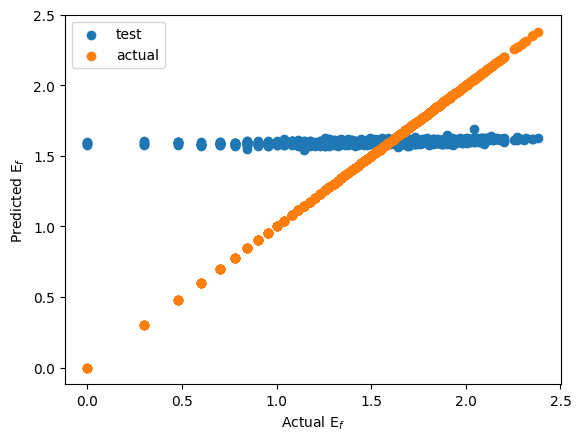

In [539]:
import matplotlib.pyplot as plt

actual = []
predicted = []

model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        y_pred = model(batch)
        predicted.extend(y_pred.data.cpu().tolist())
        actual.extend(batch.y.tolist())
        
fig, ax = plt.subplots()
ax.scatter(np.array(actual), np.array(predicted), label="test")
ax.scatter(np.array(actual), np.array(actual), label="actual")
ax.set(ylabel="Predicted E$_{f}$", xlabel="Actual E$_{f}$")
plt.legend()

Epoch: 01 | Train MAE:   0.3335 | Valid MAE:   0.3165 |   Elapsed time: 00 min 19 s
Epoch: 02 | Train MAE:   0.2978 | Valid MAE:   0.3256 |   Elapsed time: 00 min 43 s
Epoch: 03 | Train MAE:   0.2961 | Valid MAE:   0.3232 |   Elapsed time: 01 min 04 s
Epoch: 04 | Train MAE:   0.2953 | Valid MAE:   0.3243 |   Elapsed time: 02 min 00 s
Epoch: 05 | Train MAE:   0.2948 | Valid MAE:   0.3204 |   Elapsed time: 02 min 21 s
Epoch: 06 | Train MAE:   0.2945 | Valid MAE:   0.3168 |   Elapsed time: 02 min 46 s
Epoch: 07 | Train MAE:   0.2938 | Valid MAE:   0.3169 |   Elapsed time: 03 min 10 s
Epoch: 08 | Train MAE:   0.2935 | Valid MAE:   0.3148 |   Elapsed time: 03 min 34 s
Epoch: 09 | Train MAE:   0.2930 | Valid MAE:   0.3125 |   Elapsed time: 03 min 59 s
Epoch: 10 | Train MAE:   0.2926 | Valid MAE:   0.3128 |   Elapsed time: 04 min 24 s
Epoch: 11 | Train MAE:   0.2923 | Valid MAE:   0.3183 |   Elapsed time: 04 min 46 s
Epoch: 12 | Train MAE:   0.2917 | Valid MAE:   0.3080 |   Elapsed time: 05 m

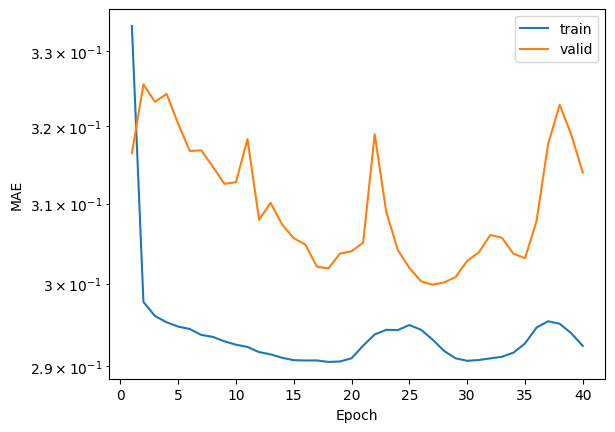

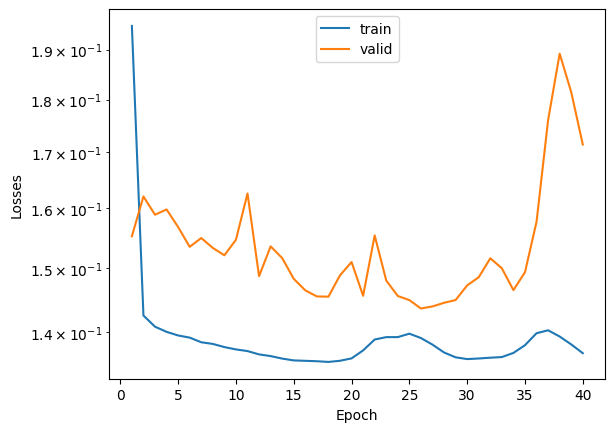

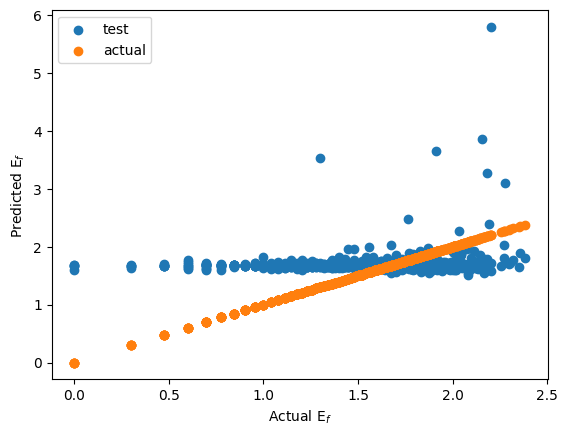

In [541]:
### Comparison with CGCNN to verify the model (will be removed at the end)
from utils import scatter_sum, scatter_mean

class GraphConvolution(nn.Module):
    
    def __init__(self, node_feat_dim, edge_feat_dim):
        """
        Convolutional layer for graphs.
        
        Parameters
        ----------
        node_feat_dim : int
          Number of node features.
        edge_feat_dim : int
          Number of edge features.
        """
        super().__init__()

        # linear layer used for the gated MLP
        self.lin1 = nn.Linear(
            2 * node_feat_dim + edge_feat_dim,
            2 * node_feat_dim,
        )

        # normalisation layers
        self.bn1 = nn.BatchNorm1d(2 * node_feat_dim)
        self.bn2 = nn.BatchNorm1d(node_feat_dim)

    def forward(self, node_feat, edge_feat, edge_src, edge_dst):
        """Perform the convolution.

        Parameters
        ----------
        node_feat : Tensor
            The node features.
        edge_feat : Tensor
            The edge features
        edge_src : Tensor
            The indices of the central nodes for the edges.
        edge_dst : Tensor
            The indices of the desintation nodes for the edges.
        """
        # concatenate node and edge features
        m = torch.cat([node_feat[edge_src], node_feat[edge_dst], edge_feat], dim=1)

        # gated MLP
        z = self.lin1(m)
        z = self.bn1(z)
        z1, z2 = z.chunk(2, dim=1)
        z1 = nn.Sigmoid()(z1)
        z2 = nn.Softplus()(z2)
        z = z1 * z2

        # pool features
        z = scatter_sum(z, edge_src, dim=0, dim_size=node_feat.shape[0])
        
        # pass through normalisation layer
        return nn.Softplus()(self.bn2(z) + node_feat)

class CGCNN(nn.Module):
    def __init__(
        self,
        node_feat_dim,
        edge_feat_dim,
        node_hidden_dim=64,
        num_graph_conv_layers=3,
        fc_feat_dim=128
    ):
        """
        Crystal Graph Convolutional Neural Network 

        Parameters
        ----------
        node_feat_dim : int
          Number of initial node features from one-hot encoding.
        edge_feat_dim : int
          Number of bond features.
        node_hidden_dim : int
          The number of features in the node embedding.
        num_graph_conv_layers: int
          Number of convolutional layers.
        fc_feat_dim: int
          Number of hidden features after pooling.
        """
        super().__init__()

        # dense layer to transform one-hot encoded node features to embedding
        self.embedding = nn.Linear(node_feat_dim, node_hidden_dim)

        # set up the convolutions
        convs = []
        for _ in range(num_graph_conv_layers):
            convs.append(GraphConvolution(node_feat_dim=node_hidden_dim, edge_feat_dim=edge_feat_dim))
        self.convs = nn.ModuleList(convs)

        # dense layer to turn final node embeddings to the crystal features
        self.conv_to_fc = nn.Sequential(
           nn.Linear(node_hidden_dim, fc_feat_dim), nn.Softplus()
        )

        # dense layer to get the final target value
        self.fc_out = nn.Linear(fc_feat_dim, 1)

    def forward(self, batch):
        """
        Predict the target property given a batch of data.

        Parameters
        ----------
        batch : Batch
            The data to pass through the network.
        """
        # get initial node embedding
        node_feat = self.embedding(batch.x)

        # apply convolutions
        for conv_func in self.convs:
            node_feat = conv_func(node_feat, batch.edge_feat, batch.edge_index[0], batch.edge_index[1])

        # pool node vectors
        crys_feat = scatter_mean(node_feat, batch.batch, dim=0, dim_size=batch.batch.max() + 1)

        # pass pooled vector through FC layer with activation
        crys_feat = self.conv_to_fc(crys_feat)

        # pass crystal features through final fully-connected layer
        return self.fc_out(crys_feat)



# Instantiate the model
hidden_channels = 64
max_epoch       = 40

in_node_features = 118 #node_features.shape[1]##Because the one-hot encoding is the same for all the nodes, we can take this value.
in_edge_features = 10
model = CGCNN(in_node_features,in_edge_features, hidden_channels,num_graph_conv_layers=3)

# Optimizer and loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # We use a basic Adam optimizer.
criterion = torch.nn.MSELoss()  # Use CrossEntropyLoss for classification tasks

start_time = time.time()
save_losses_train = []
save_losses_valid = []
save_mae_train = []
save_mae_valid = []
# Using the DataLoaders for training and validation
for epoch in range(0,max_epoch):
    train_loss,train_mae = train(train_loader,model,optimizer,criterion)
    val_loss,valid_mae = evaluate(val_loader,model,criterion)
    # Save validation and losses.
    save_losses_train.append(train_loss)
    save_losses_valid.append(val_loss)
    save_mae_train.append(train_mae)
    save_mae_valid.append(valid_mae)
    #
    epoch_time = time.time() - start_time
    print(f'Epoch: {epoch+1:02} | Train MAE: {train_mae:8.4f} | Valid MAE: {valid_mae:8.4f}'
         f' |   Elapsed time: {time.strftime("%M min %S s", time.gmtime(epoch_time))}')
# Test the model
test_loss,test_mae = evaluate(test_loader,model,criterion)
print(f'Test Loss: {test_loss:.4f} | Test MAE: {test_mae:.4f}')




fig, ax = plt.subplots()
ax.plot(range(1,max_epoch+1), save_mae_train, label="train")
ax.plot(range(1,max_epoch+1), save_mae_valid, label="valid")
ax.set(xlabel="Epoch", ylabel="MAE")
ax.set_yscale("log")
plt.legend()

fig, ax = plt.subplots()
ax.plot(range(1,max_epoch+1), save_losses_train, label="train")
ax.plot(range(1,max_epoch+1), save_losses_valid, label="valid")
ax.set(xlabel="Epoch", ylabel="Losses")
ax.set_yscale("log")
plt.legend()

import matplotlib.pyplot as plt

actual = []
predicted = []

model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        y_pred = model(batch)
        predicted.extend(y_pred.data.cpu().tolist())
        actual.extend(batch.y.tolist())
        
fig, ax = plt.subplots()
ax.scatter(np.array(actual), np.array(predicted), label="test")
ax.scatter(np.array(actual), np.array(actual), label="actual")
ax.set(ylabel="Predicted E$_{f}$", xlabel="Actual E$_{f}$")
plt.legend()